In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DATA = {
    "10 industries": "csv/10_industry.csv",
    "30 industries": "csv/30_industry.csv",
}

TRAIN_START = "2000-01-01"
TRAIN_END   = "2012-12-31"      # fold 1 학습 구간
LB_LIST     = [252, 504]        # 1년, 2년
STEP        = 21                # 한 달씩 rolling (overlapping)
HORIZON_CUR = 126               # 현재 사용 중인 horizon (참고선)


def load_returns(path):
    df = pd.read_csv(path).set_index("Date")
    idx = pd.to_datetime(df.index, format="%Y%m%d", errors="coerce")
    if idx.isna().any():
        idx = pd.to_datetime(df.index, errors="coerce")
    df.index = idx
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    return df / 100.0


rets = {}
for name, path in DATA.items():
    d = load_returns(path).loc[TRAIN_START:TRAIN_END]
    rets[name] = d
    print(f"{name:15s}  {d.shape[0]:5d}일 × {d.shape[1]:2d}개  "
          f"{d.index[0].date()} ~ {d.index[-1].date()}")

10 industries     3269일 × 10개  2000-01-03 ~ 2012-12-31
30 industries     3269일 × 30개  2000-01-03 ~ 2012-12-31


In [2]:
def mdd_episode(path):
    """
    누적경로에서 최대 drawdown 에피소드를 찾아 (크기, 하락기간, 회복포함기간) 반환.

    path : 1D array, 누적 수익 경로

    Returns
    -------
    dict
      mdd          : 최대 낙폭 (절대값)
      peak, trough : 인덱스
      dur_decline  : peak → trough 거래일수
      dur_recovery : peak → 회복 시점 거래일수 (구간 내 미회복이면 NaN)
    """
    path   = np.asarray(path, dtype=float)
    runmax = np.maximum.accumulate(path)
    dd     = runmax - path

    trough = int(np.argmax(dd))
    peak   = int(np.argmax(path[:trough + 1])) if trough > 0 else 0

    # 회복: trough 이후 처음으로 peak 수준을 회복하는 시점
    after = np.where(path[trough:] >= path[peak])[0]
    dur_recovery = float(trough + after[0] - peak) if len(after) else np.nan

    return {
        "mdd"         : float(dd[trough]),
        "peak"        : peak,
        "trough"      : trough,
        "dur_decline" : float(trough - peak),
        "dur_recovery": dur_recovery,
    }


def cum_path(r, compounded=False):
    """일별 수익률 → 누적경로. 기본은 가산(uncompounded, 논문 제약식과 동일 기준)."""
    return np.cumprod(1 + r) - 1 if compounded else np.cumsum(r)

In [3]:
records = []

for ds_name, d in rets.items():
    R      = d.values                      # (T, m)
    dates  = d.index
    T, m   = R.shape
    ew     = R.mean(axis=1)                # 동일가중 포트폴리오

    for LB in LB_LIST:
        if T < LB:
            continue
        for s in range(0, T - LB + 1, STEP):
            e = s + LB
            win_start, win_end = dates[s], dates[e - 1]

            for compounded in (False, True):
                # ── 동일가중 포트폴리오 ──
                ep = mdd_episode(cum_path(ew[s:e], compounded))
                records.append({
                    "dataset": ds_name, "LB": LB,
                    "start": win_start, "end": win_end,
                    "series": "EW portfolio", "asset": "EW",
                    "compounded": compounded, **ep,
                })

                # ── 산업별 개별 ──
                for j, col in enumerate(d.columns):
                    ep = mdd_episode(cum_path(R[s:e, j], compounded))
                    records.append({
                        "dataset": ds_name, "LB": LB,
                        "start": win_start, "end": win_end,
                        "series": "Individual", "asset": col,
                        "compounded": compounded, **ep,
                    })

dur = pd.DataFrame(records)
print(f"총 {len(dur):,}개 에피소드")
print(dur.groupby(["dataset", "LB", "series", "compounded"]).size()
         .rename("n").to_frame())

총 23,184개 에피소드
                                              n
dataset       LB  series       compounded      
10 industries 252 EW portfolio False        144
                               True         144
                  Individual   False       1440
                               True        1440
              504 EW portfolio False        132
                               True         132
                  Individual   False       1320
                               True        1320
30 industries 252 EW portfolio False        144
                               True         144
                  Individual   False       4320
                               True        4320
              504 EW portfolio False        132
                               True         132
                  Individual   False       3960
                               True        3960


In [4]:
def summarize(sub, col="dur_decline"):
    v = sub[col].dropna()
    return pd.Series({
        "n"      : len(v),
        "mean"   : v.mean(),
        "median" : v.median(),
        "p75"    : v.quantile(0.75),
        "p90"    : v.quantile(0.90),
        "p95"    : v.quantile(0.95),
        "max"    : v.max(),
        f"≤{HORIZON_CUR}일 비율": (v <= HORIZON_CUR).mean(),
    })

for col, tag in [("dur_decline", "하락 기간 (peak → trough)"),
                 ("dur_recovery", "회복 포함 기간 (peak → recovery)")]:
    print(f"\n{'='*78}\n  {tag}  — 단위: 거래일\n{'='*78}")
    tbl = (dur[~dur["compounded"]]
           .groupby(["dataset", "LB", "series"])
           .apply(lambda g: summarize(g, col)))
    display(tbl.round(1))


  하락 기간 (peak → trough)  — 단위: 거래일


/var/folders/j4/2041ftmn23q6ckn4xskb5z9c0000gn/T/ipykernel_55212/3110883641.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: summarize(g, col)))


n   mean  median    p75    p90    p95  \
dataset       LB  series                                                     
10 industries 252 EW portfolio   144.0   63.9    44.0   82.5  141.0  188.2   
                  Individual    1440.0   68.3    49.0   90.0  156.0  194.0   
              504 EW portfolio   132.0  119.2    61.0  185.2  346.0  352.0   
                  Individual    1320.0  126.3    87.0  177.0  310.0  352.0   
30 industries 252 EW portfolio   144.0   59.0    42.0   61.0  137.3  181.9   
                  Individual    4320.0   69.1    51.0   93.0  146.0  190.0   
              504 EW portfolio   132.0  116.1    61.0  150.5  339.0  344.9   
                  Individual    3960.0  121.2    88.0  158.0  288.0  354.0   

                                  max  ≤126일 비율  
dataset       LB  series                         
10 industries 252 EW portfolio  249.0       0.8  
                  Individual    251.0       0.8  
              504 EW portfolio  352.0       0.7  
                  Individual    503.0       0.6  
30 industries 252 EW portfolio  240.0       0.9  
                  Individual    251.0       0.9  
              504 EW portfolio  346.0       0.7  
                  Individual    503.0       0.7


  회복 포함 기간 (peak → recovery)  — 단위: 거래일


/var/folders/j4/2041ftmn23q6ckn4xskb5z9c0000gn/T/ipykernel_55212/3110883641.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: summarize(g, col)))


n   mean  median    p75    p90    p95  \
dataset       LB  series                                                     
10 industries 252 EW portfolio    80.0   81.5    71.0  117.0  139.0  174.0   
                  Individual     707.0   91.5    85.0  122.0  164.4  186.0   
              504 EW portfolio    72.0  147.9    81.0  139.0  388.7  428.0   
                  Individual     712.0  175.1   146.0  232.0  357.0  396.4   
30 industries 252 EW portfolio    79.0   84.6    78.0  110.0  146.0  147.6   
                  Individual    2034.0   95.1    88.0  127.0  166.0  191.3   
              504 EW portfolio    73.0  162.8   110.0  180.0  367.0  374.6   
                  Individual    2194.0  182.4   156.0  257.2  358.0  393.0   

                                  max  ≤126일 비율  
dataset       LB  series                         
10 industries 252 EW portfolio  179.0       0.8  
                  Individual    242.0       0.8  
              504 EW portfolio  452.0       0.6  
                  Individual    503.0       0.4  
30 industries 252 EW portfolio  188.0       0.9  
                  Individual    249.0       0.7  
              504 EW portfolio  453.0       0.6  
                  Individual    499.0       0.4

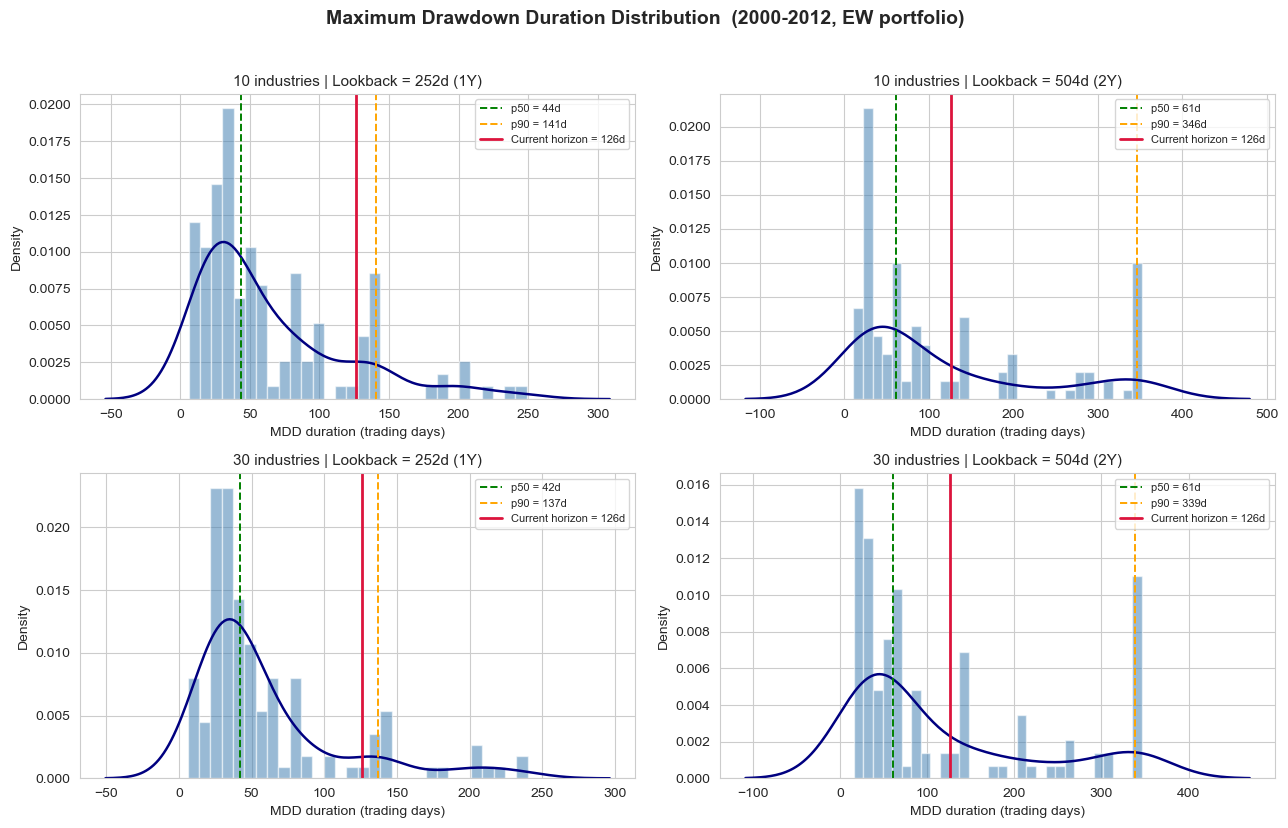

In [6]:
COL = "dur_decline"        # or "dur_recovery"

sub = dur[(~dur["compounded"]) & (dur["series"] == "EW portfolio")]

fig, axes = plt.subplots(len(DATA), len(LB_LIST),
                         figsize=(6.5 * len(LB_LIST), 4.2 * len(DATA)),
                         squeeze=False)

for i, ds_name in enumerate(DATA):
    for j, LB in enumerate(LB_LIST):
        ax = axes[i][j]
        v  = sub[(sub.dataset == ds_name) & (sub.LB == LB)][COL].dropna()
        if v.empty:
            ax.set_visible(False); continue

        ax.hist(v, bins=30, density=True, alpha=0.55,
                color="steelblue", edgecolor="white")
        sns.kdeplot(v, ax=ax, color="navy", lw=1.8)

        for q, c in [(0.50, "green"), (0.90, "orange")]:
            ax.axvline(v.quantile(q), color=c, ls="--", lw=1.4,
                       label=f"p{int(q*100)} = {v.quantile(q):.0f}d")
        ax.axvline(HORIZON_CUR, color="crimson", lw=2,
                   label=f"Current horizon = {HORIZON_CUR}d")

        yrs = "1Y" if LB == 252 else "2Y"
        ax.set_title(f"{ds_name} | Lookback = {LB}d ({yrs})", fontsize=11)
        ax.set_xlabel("MDD duration (trading days)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

fig.suptitle("Maximum Drawdown Duration Distribution  (2000-2012, EW portfolio)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()